In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import r2_score
import joblib

In [2]:
df = pd.read_csv("House_price.csv")
df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [6]:
#Drop Id Column
df.drop(["Id"], axis=1, inplace=True)

In [7]:
 df = df[df["SalePrice"].notna()]   # keep only rows with real labels
    # then proceed with dropna() for other columns

In [8]:
#Checking the data isNull Value is exixst
df.head()
df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [9]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [11]:
X.head

<bound method NDFrame.head of       MSSubClass  LotArea  OverallCond  YearBuilt  YearRemodAdd  BsmtFinSF2  \
0             60     8450            5       2003          2003         0.0   
1             20     9600            8       1976          1976         0.0   
2             60    11250            5       2001          2002         0.0   
3             70     9550            5       1915          1970         0.0   
4             60    14260            5       2000          2000         0.0   
...          ...      ...          ...        ...           ...         ...   
1455          60     7917            5       1999          2000         0.0   
1456          20    13175            6       1978          1988       163.0   
1457          70     9042            9       1941          2006         0.0   
1458          20     9717            6       1950          1996      1029.0   
1459          20     9937            6       1965          1965       290.0   

      TotalBsmtSF  MS

In [12]:
X_train, X_test, y_train,y_test = train_test_split(
X, y,test_size = 0.2, random_state = 42)

In [13]:
X_train

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
254,20,8400,6,1957,1957,0.0,1314.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
1066,60,7837,7,1993,1994,0.0,799.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
638,30,8777,7,1910,1950,0.0,796.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
799,50,7200,7,1937,1950,0.0,731.0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
380,50,5000,6,1924,1950,0.0,1026.0,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20,9317,5,2006,2006,0.0,1314.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1130,50,7804,3,1928,1950,0.0,1122.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1294,20,8172,7,1955,1990,0.0,864.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
860,50,7642,8,1918,1998,0.0,912.0,False,False,True,...,False,False,False,False,False,False,False,False,True,False


In [14]:
X_test

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
892,20,8414,8,1963,2003,0.0,1059.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1105,60,12256,5,1994,1995,0.0,1463.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
413,30,8960,6,1927,1950,0.0,1008.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
522,50,5000,7,1947,1950,0.0,1004.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1036,20,12898,5,2007,2008,0.0,1620.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,30,5925,7,1937,2000,0.0,907.0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1361,20,16158,5,2005,2005,0.0,1530.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
802,60,8199,5,2005,2005,0.0,728.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
651,70,9084,5,1940,1950,0.0,755.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MSSubClass           1460 non-null   int64  
 1   LotArea              1460 non-null   int64  
 2   OverallCond          1460 non-null   int64  
 3   YearBuilt            1460 non-null   int64  
 4   YearRemodAdd         1460 non-null   int64  
 5   BsmtFinSF2           1460 non-null   float64
 6   TotalBsmtSF          1460 non-null   float64
 7   SalePrice            1460 non-null   float64
 8   MSZoning_FV          1460 non-null   bool   
 9   MSZoning_RH          1460 non-null   bool   
 10  MSZoning_RL          1460 non-null   bool   
 11  MSZoning_RM          1460 non-null   bool   
 12  LotConfig_CulDSac    1460 non-null   bool   
 13  LotConfig_FR2        1460 non-null   bool   
 14  LotConfig_FR3        1460 non-null   bool   
 15  LotConfig_Inside     1460 non-null   bool  

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")   # save so you can reuse on new data
print("Scaler saved to scaler.pkl")

Scaler saved to scaler.pkl


In [17]:
X_train_scaled

array([[-0.8667643 , -0.21289571,  0.3722173 , ..., -0.74933125,
        -0.41414314, -0.12859284],
       [ 0.07410996, -0.26524463,  1.26860866, ...,  1.33452328,
        -0.41414314, -0.12859284],
       [-0.63154574, -0.17784146,  1.26860866, ..., -0.74933125,
        -0.41414314, -0.12859284],
       ...,
       [-0.8667643 , -0.23409563,  1.26860866, ..., -0.74933125,
        -0.41414314,  7.77648277],
       [-0.16110861, -0.28337613,  2.16500001, ..., -0.74933125,
         2.41462406, -0.12859284],
       [ 1.48542135, -0.65139925, -0.52417405, ...,  1.33452328,
        -0.41414314, -0.12859284]], shape=(1168, 33))

In [18]:
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

In [19]:
type(X_train_scaled)

numpy.ndarray

In [20]:
type(y_train)
y_train.shape

(1168,)

In [21]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [22]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

### DEEP LEARNING 

In [23]:
# Define the ANN Model
class ANN(nn.Module):
    def __init__(self, input_dim):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model     = ANN(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

ANN(
  (model): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [24]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 200

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()  # reset gradients

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

Epoch [1/200] Train Loss: 38830244780.9730 | Val Loss: 39038163148.8000
Epoch [2/200] Train Loss: 39071258457.9459 | Val Loss: 39035653120.0000
Epoch [3/200] Train Loss: 38915006962.1622 | Val Loss: 39029905817.6000
Epoch [4/200] Train Loss: 38811310080.0000 | Val Loss: 39022089011.2000
Epoch [5/200] Train Loss: 38854648859.6757 | Val Loss: 39008990208.0000
Epoch [6/200] Train Loss: 38656194726.0541 | Val Loss: 38988679987.2000
Epoch [7/200] Train Loss: 38767377491.0270 | Val Loss: 38959638528.0000
Epoch [8/200] Train Loss: 38651639199.1351 | Val Loss: 38928186777.6000
Epoch [9/200] Train Loss: 38841067962.8108 | Val Loss: 38875844403.2000
Epoch [10/200] Train Loss: 38820460211.8919 | Val Loss: 38822178816.0000
Epoch [11/200] Train Loss: 38491630342.9189 | Val Loss: 38724779827.2000
Epoch [12/200] Train Loss: 38430630054.0541 | Val Loss: 38661002854.4000
Epoch [13/200] Train Loss: 38391037343.1351 | Val Loss: 38549098086.4000
Epoch [14/200] Train Loss: 38532961030.9189 | Val Loss: 3845

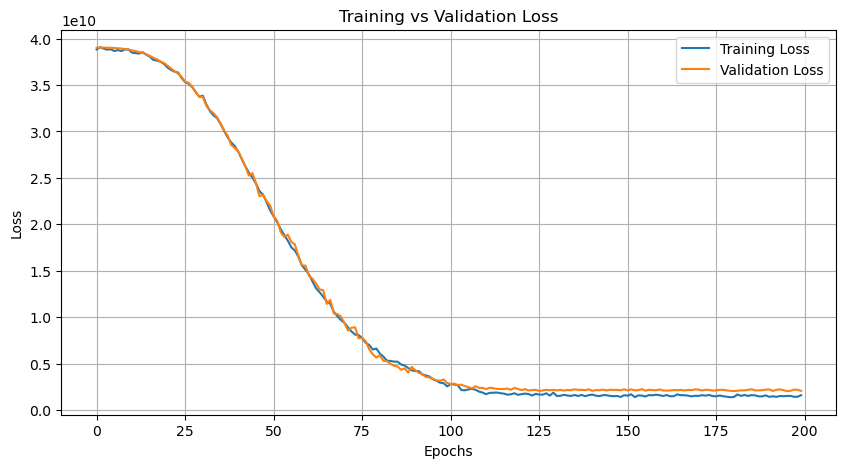

In [25]:
# Plot
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(10, 5))
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
#Saving and Loading Best Model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [27]:
#Evaluate the Model
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 768197952.0
Testing MSE: 2193161728.0


In [28]:
print("r2_score value: ", r2_score(y_test, test_pred.numpy()))

r2_score value:  0.714071889560234


In [29]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=["predicted_values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual_values"])

pd.concat([predicted_df,actual_df],axis = 1)

,predicted_values,Actual_values
0,151264.625000,154500.0
1,273043.093750,325000.0
2,117561.617188,115000.0
3,116369.890625,159000.0
4,266619.875000,315500.0
...,...,...
287,174890.734375,89471.0
288,248813.671875,260000.0
289,210674.640625,189000.0
290,134659.656250,108000.0
